In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # Use GPU if available
device

device(type='cuda', index=0)

In [2]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
#print total number of words and characters in the vocabulary
print(f'{len(words)} words, {len(chars)} unique characters')

32033 words, 26 unique characters


In [3]:
# Build the dataset
block_size = 3  # context length: how many characters used to predict the next? (1 before)
X, Y = [], []   # features (input) and labels (output)

# Just show the first three words as example
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        
        X.append(context)
        Y.append(ix)
        
        # Showing what input and expected output now look like
        context = context[1:] + [ix] # crop and append, like a rolling window; NEAT!

# These DO NOT carry characters, but their respective index numbers
X = torch.tensor(X, device=device)
Y = torch.tensor(Y, device=device)

print('Input:', X.shape, X.dtype, X[0])
print('Output:', Y.shape, Y.dtype, Y[0]) 

Input: torch.Size([228146, 3]) torch.int64 tensor([0, 0, 0], device='cuda:0')
Output: torch.Size([228146]) torch.int64 tensor(5, device='cuda:0')


In [4]:
g = torch.Generator(device=device).manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g, device=device)     #  27 characters, 2 dimensions each
W1 = torch.randn((6,100), generator=g, device=device)   #   3 characters times 2 embedding values as inputs to 100 neurons
b1 = torch.randn((100), generator=g, device=device)     # 100 biases added to the 100 neuron outputs
W2 = torch.randn((100,27), generator=g, device=device)  # 100 neuron outputs as inputs to 27 output neurons
b2 = torch.randn((27), generator=g, device=device)      #  27 biases added to the 27 output neurons

parameters = [C, W1, b1, W2, b2] # Cluster all parameters into one structure

print(sum(p.nelement() for p in parameters), 'parameters') # Network stays the same, so same number of parameters

# Allowing for gradient accumulation
for p in parameters:
    p.requires_grad = True

3481 parameters


In [6]:
# For the 32 input dataset, we had used 1000 epochs
# Now, for the much larger dataset, we can reduce this to 10 epochs
lossi = []
stepi = []
i = 0
for i in range(7000):
    # mini-batch construction -> 32 indices of 3-dimensional character index vectors within X
    ix = torch.randint(0, X.shape[0], (32,))

    ## Forward-Pass
    emb = C[X[ix]] # (32, 3, 2), a single batch, X[ix] grabs only the 32 indices, C then grabs the 2-dimensional vectors for each of the 3 characters for the current of the 32 triplets
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
   
    loss = F.cross_entropy(logits, Y[ix])# Y[ix] grabs the 32 expected output indices for the current batch (very elegant)
    
    lossi.append(loss.item())
    stepi.append(i)
    print(loss.item())

    # Learning rate decay to more closely approach the minimum
    lr = 0.1 if i < 50000 else 0.01    

    ## Backward-Pass
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    # Update
    for p in parameters:
        p.data += -lr * p.grad

2.867422580718994
2.0921096801757812
2.4452271461486816
2.794987916946411
2.1584012508392334
1.9542064666748047
2.2181594371795654
2.93638277053833
2.25131893157959
2.445692300796509
2.351717472076416
2.209566593170166
2.210118055343628
2.3299460411071777
2.645895481109619
2.8528406620025635
2.038792610168457
2.3944270610809326
2.097867012023926
2.2036383152008057
2.345823049545288
2.3870556354522705
2.5062685012817383
2.6900582313537598
2.5812270641326904
2.3729028701782227
2.321377754211426
2.332026720046997
2.768733263015747
2.2272543907165527
2.0703938007354736
2.7223029136657715
2.3136518001556396
2.0390517711639404
2.4944229125976562
2.443510055541992
2.319638252258301
2.3557796478271484
2.248955488204956
2.6816933155059814
2.31901216506958
2.294053554534912
2.1180245876312256
2.5249733924865723
2.431570529937744
2.123094081878662
2.618637800216675
2.0990986824035645
2.595367193222046
2.550227403640747
2.1871042251586914
2.209548234939575
2.2577364444732666
2.381060838699341
2.31

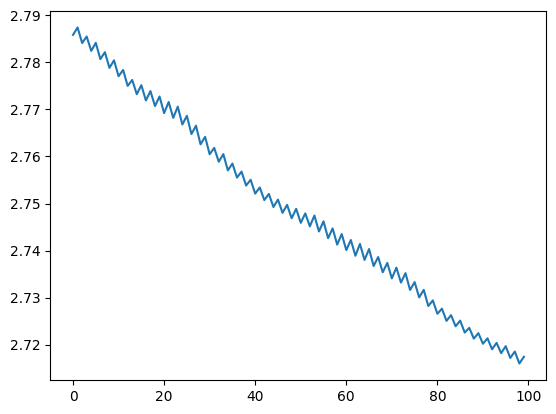

In [28]:
plt.plot(stepi, lossi);

In [35]:
# sample from the model
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break
            
    print(''.join(itos[i] for i in out))

bbkntsn.
ymenmarirenajrnh.
rdr.
leye.
lidzaomurahhecanrh.
aro.
dgeeih.
lsin.
mer.
tarelcohiaasstttatt.
kerhecdynazr.
hraan.
jeilana.
doina.
ari.
imohihekzxlas.
aarsveng.
baan.
jxcezar.
gieirei.
